In [3]:
import os
import argparse
import json
import numpy as np
import torch
import random
import time
from pathlib import Path
from models.SSSD_ECG import SSSD_ECG
from utils.util import find_max_epoch, print_size, sampling_label, calc_diffusion_hyperparams

/home/nutansahoo/miniconda3/envs/MGB-MAIDAP2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%
Falling back on slow Cauchy kernel. Install at least one of pykeops or the CUDA extension for efficiency.


In [4]:
import ecg_plot

In [5]:

def generate_four_leads(tensor):
    leadI = tensor[:,0,:].unsqueeze(1)
    leadschest = tensor[:,1:7,:]
    leadavf = tensor[:,7,:].unsqueeze(1)

    leadII = (0.5*leadI) + leadavf

    leadIII = -(0.5*leadI) + leadavf
    leadavr = -(0.75*leadI) -(0.5*leadavf)
    leadavl = (0.75*leadI) - (0.5*leadavf)

    leads12 = torch.cat([leadI, leadII, leadschest, leadIII, leadavr, leadavl, leadavf], dim=1)

    return leads12

In [6]:
with open('config/SSSD_ECG_inference.json', 'r') as file:
    config = json.load(file)
model_config = config['wavenet_config']

In [12]:
diffusion_hyperparams = calc_diffusion_hyperparams(**config["diffusion_config"] )

In [7]:
model_path = '/home/shared/output_sssd-ecg/reproduce/ch256_T200_betaT0.02/128000_job2.pkl'

checkpoint = torch.load(model_path, map_location='cpu')
net = SSSD_ECG(**model_config).cuda()
net.load_state_dict(checkpoint['model_state_dict'])



label_path = os.path.join('/home/shared/ptbxl_data_sssd-ecg', 'labels')
print ("LABEL PATH", label_path)
labels = np.load(os.path.join(label_path, 'ptbxl_train_labels.npy'))

/tmp/ipykernel_1180174/1064352423.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location='cpu')
/home/nutansahoo/miniconda3/env

LABEL PATH /home/shared/ptbxl_data_sssd-ecg/labels


In [4]:
label_path = os.path.join('/home/shared/ptbxl_data_sssd-ecg', 'labels')
print ("LABEL PATH", label_path)
labels = np.load(os.path.join(label_path, 'ptbxl_train_labels.npy'))

LABEL PATH /home/shared/ptbxl_data_sssd-ecg/labels


In [11]:
path = '/home/shared/output_sssd-ecg/reproduce/ch256_T200_betaT0.02/synth_data_melspectrogram_loss_final/train/synth_data_melspec_loss_final/'+'32_samples.npy'
t = np.load(path)
t.shape

(400, 12, 1000)

In [15]:
t[0][0]

array([-3.59684303e-02, -3.31568904e-02, -3.42568047e-02, -3.14917788e-02,
       -1.78657845e-02, -1.16434647e-02, -1.58374459e-02, -2.20530797e-02,
       -2.11303309e-02, -1.38349282e-02, -6.65017311e-03, -9.88337677e-03,
       -1.42652972e-03,  1.08006457e-02,  2.00238768e-02,  3.86673771e-02,
        6.45109639e-02,  9.84109342e-02,  1.32140592e-01,  1.55313432e-01,
        1.75351158e-01,  1.84552044e-01,  1.58482000e-01,  1.34784669e-01,
        1.12753175e-01,  6.95734844e-02,  2.54248958e-02, -1.55446213e-02,
       -3.46407294e-02, -4.60147746e-02, -5.78110255e-02, -5.60748391e-02,
       -5.15628122e-02, -5.39866127e-02, -5.96550032e-02, -6.38380945e-02,
       -6.50517344e-02, -6.69827089e-02, -6.32048622e-02, -6.58495873e-02,
       -6.96672499e-02, -6.73129931e-02, -6.67045787e-02, -7.13014454e-02,
       -7.03098476e-02, -6.51741549e-02, -6.79346174e-02, -7.69466832e-02,
       -8.40009302e-02, -8.64864290e-02, -8.15875977e-02, -7.73210675e-02,
       -7.95951039e-02, -

In [8]:
chunks = []
for i in range(0, len(labels), 10):
    if i + 10 <= len(labels):
        chunks.append(labels[i:i+10])
    else:
        chunks.append(labels[i:])
    break

print("Starting generation")
tik = time.time()
for i, label in enumerate(chunks):
    # if i!=len(chunks)-1:
    #     continue
    cond = torch.from_numpy(label).cuda().float()
    break

Starting generation


In [13]:
generated_audio = sampling_label(net, (10,8,1000), 
                        diffusion_hyperparams,
                        cond=cond)

generated_audio12 = generate_four_leads(generated_audio)

begin sampling, total number of reverse steps = 200


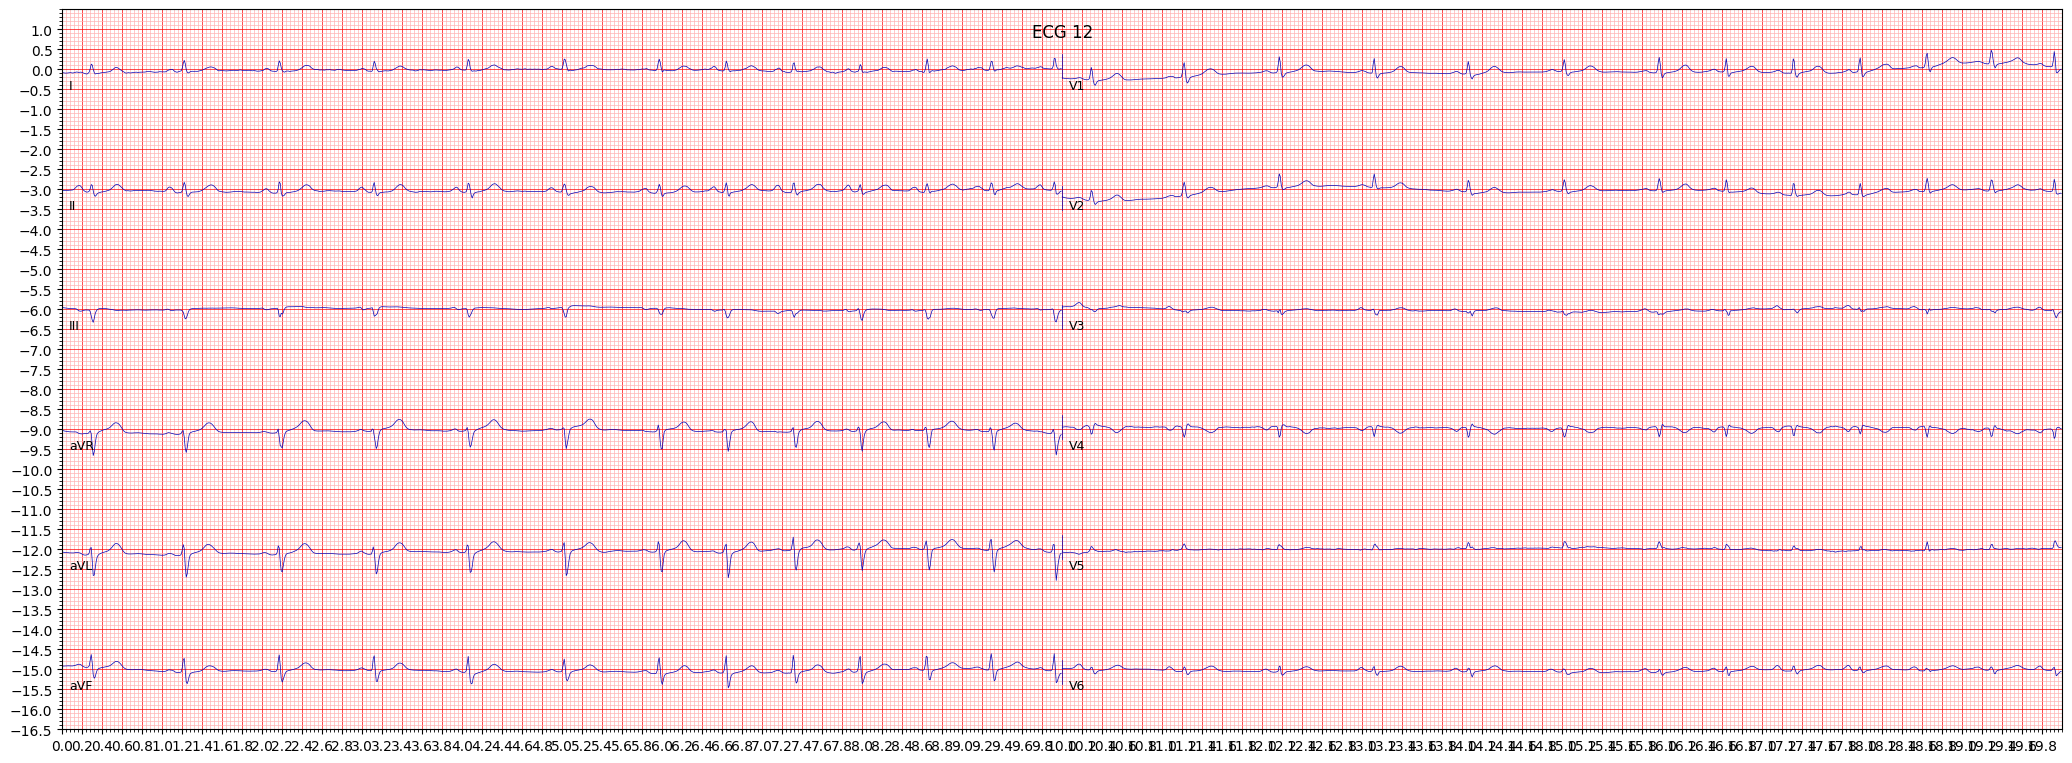

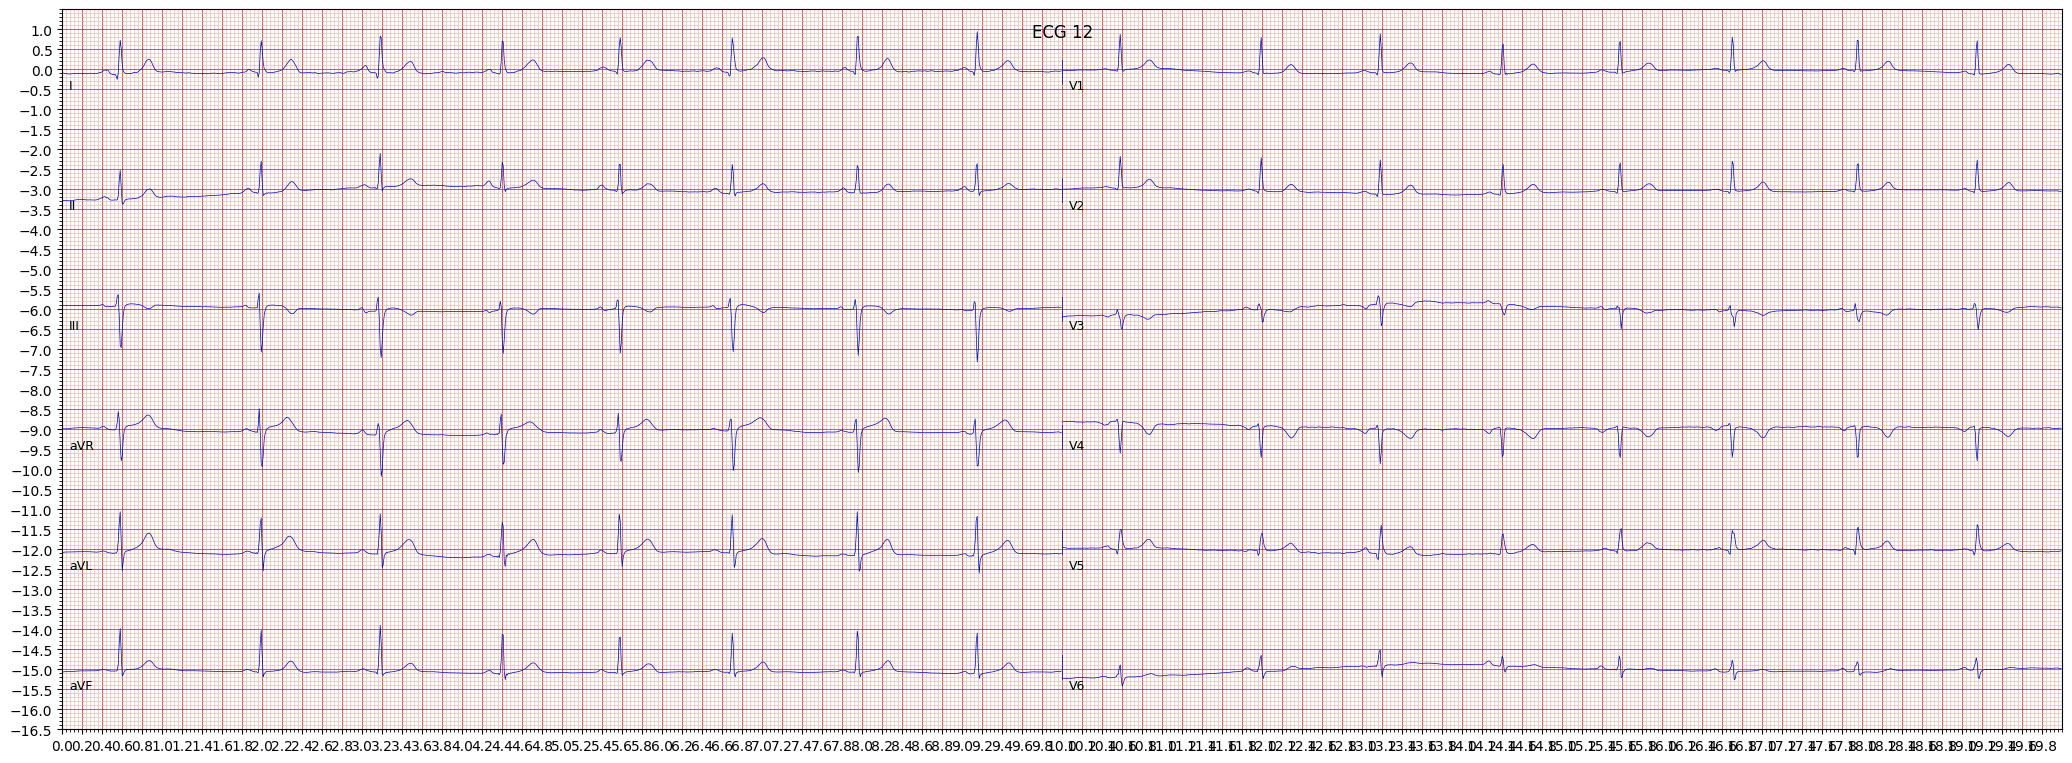

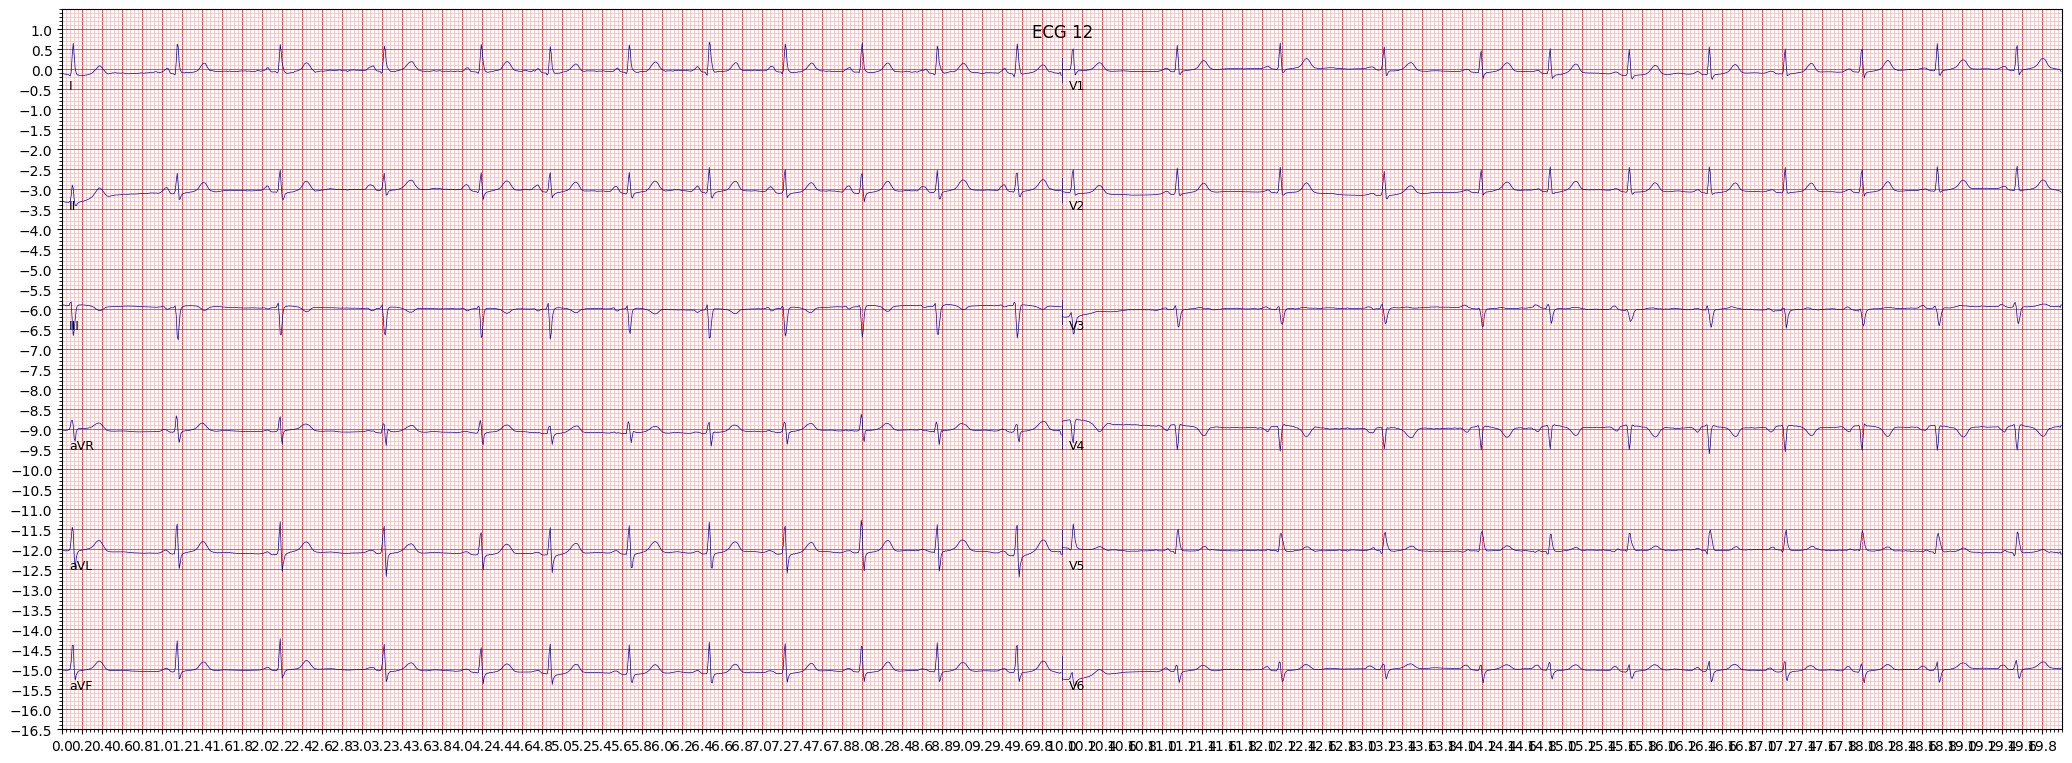

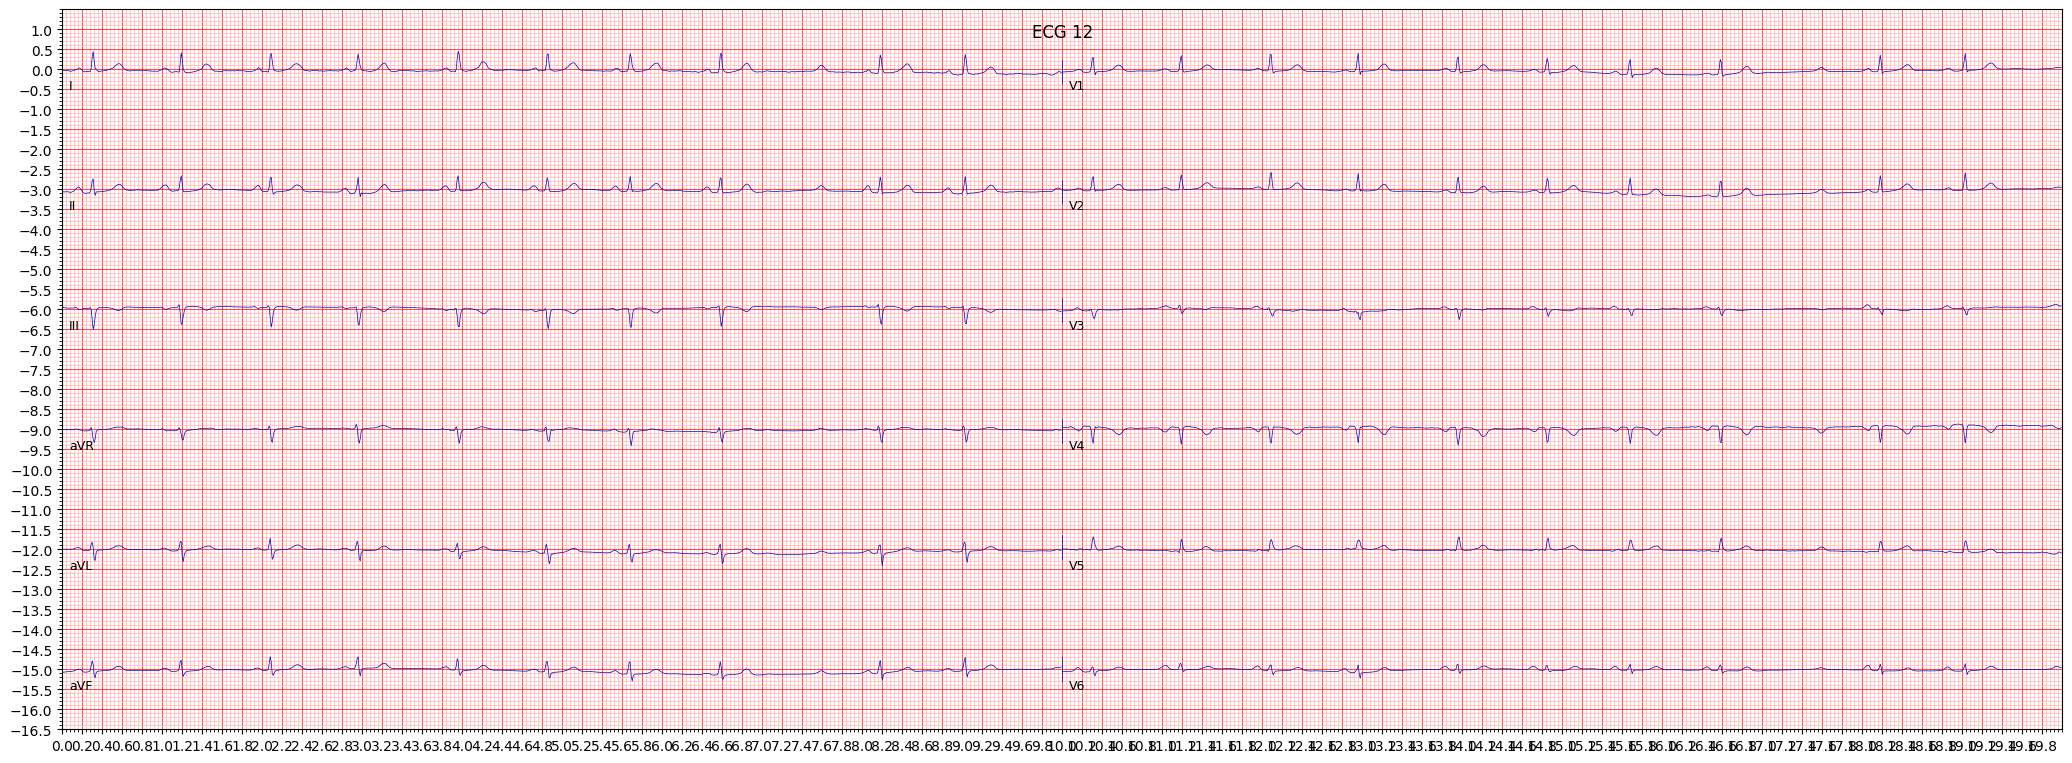

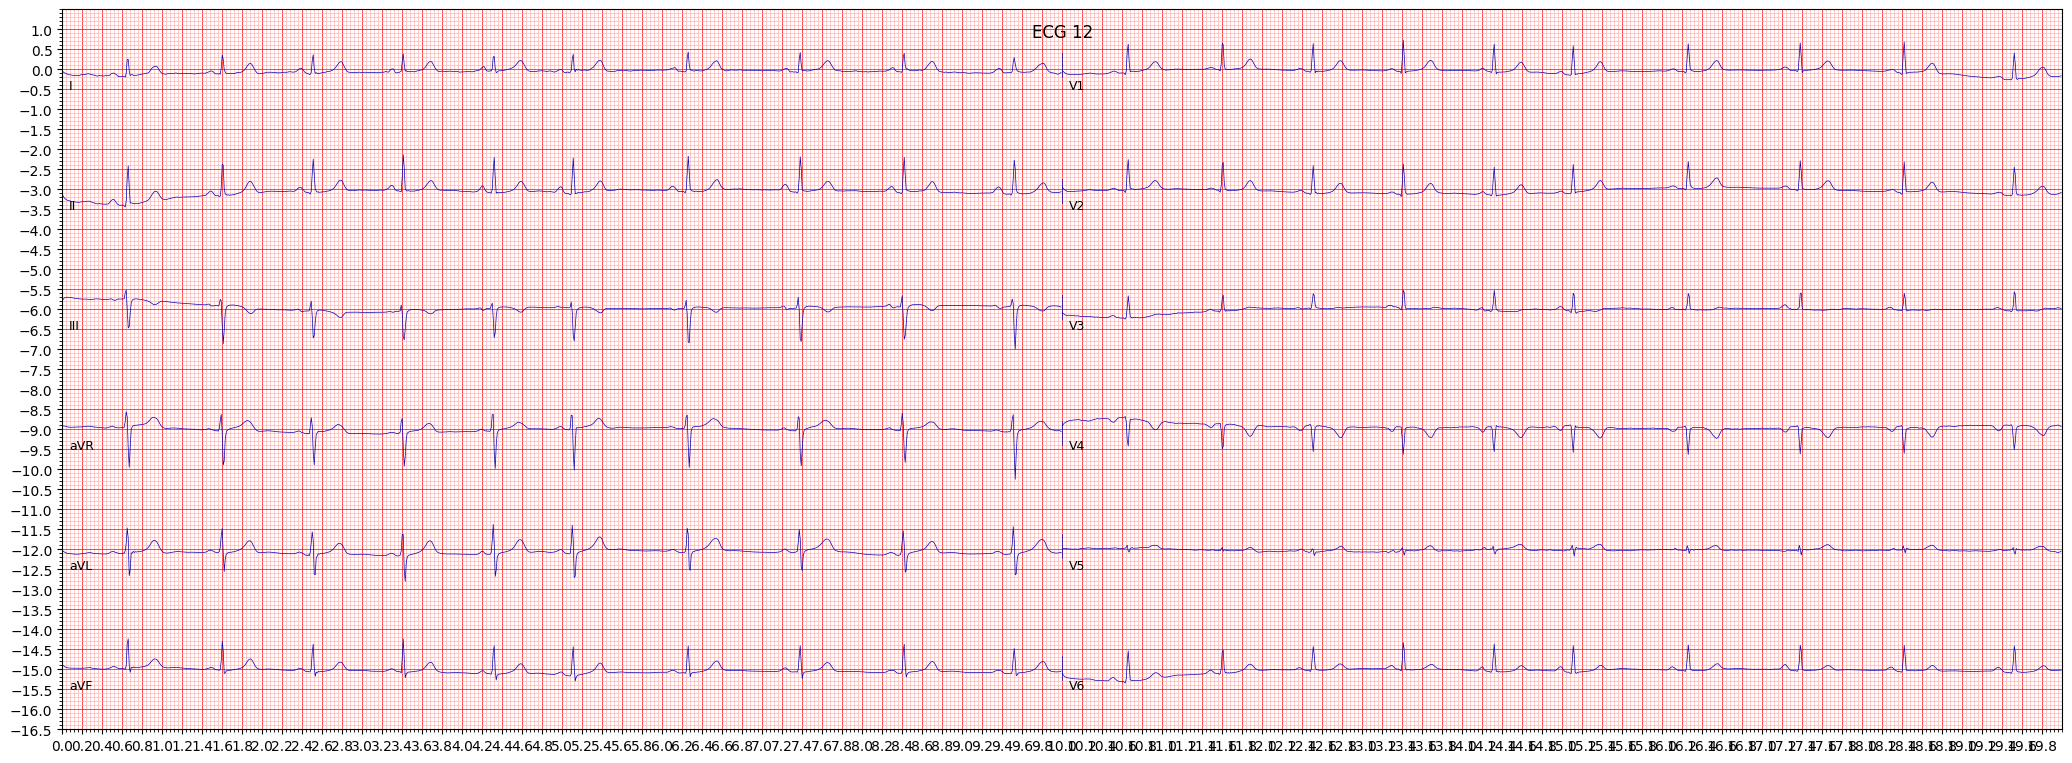

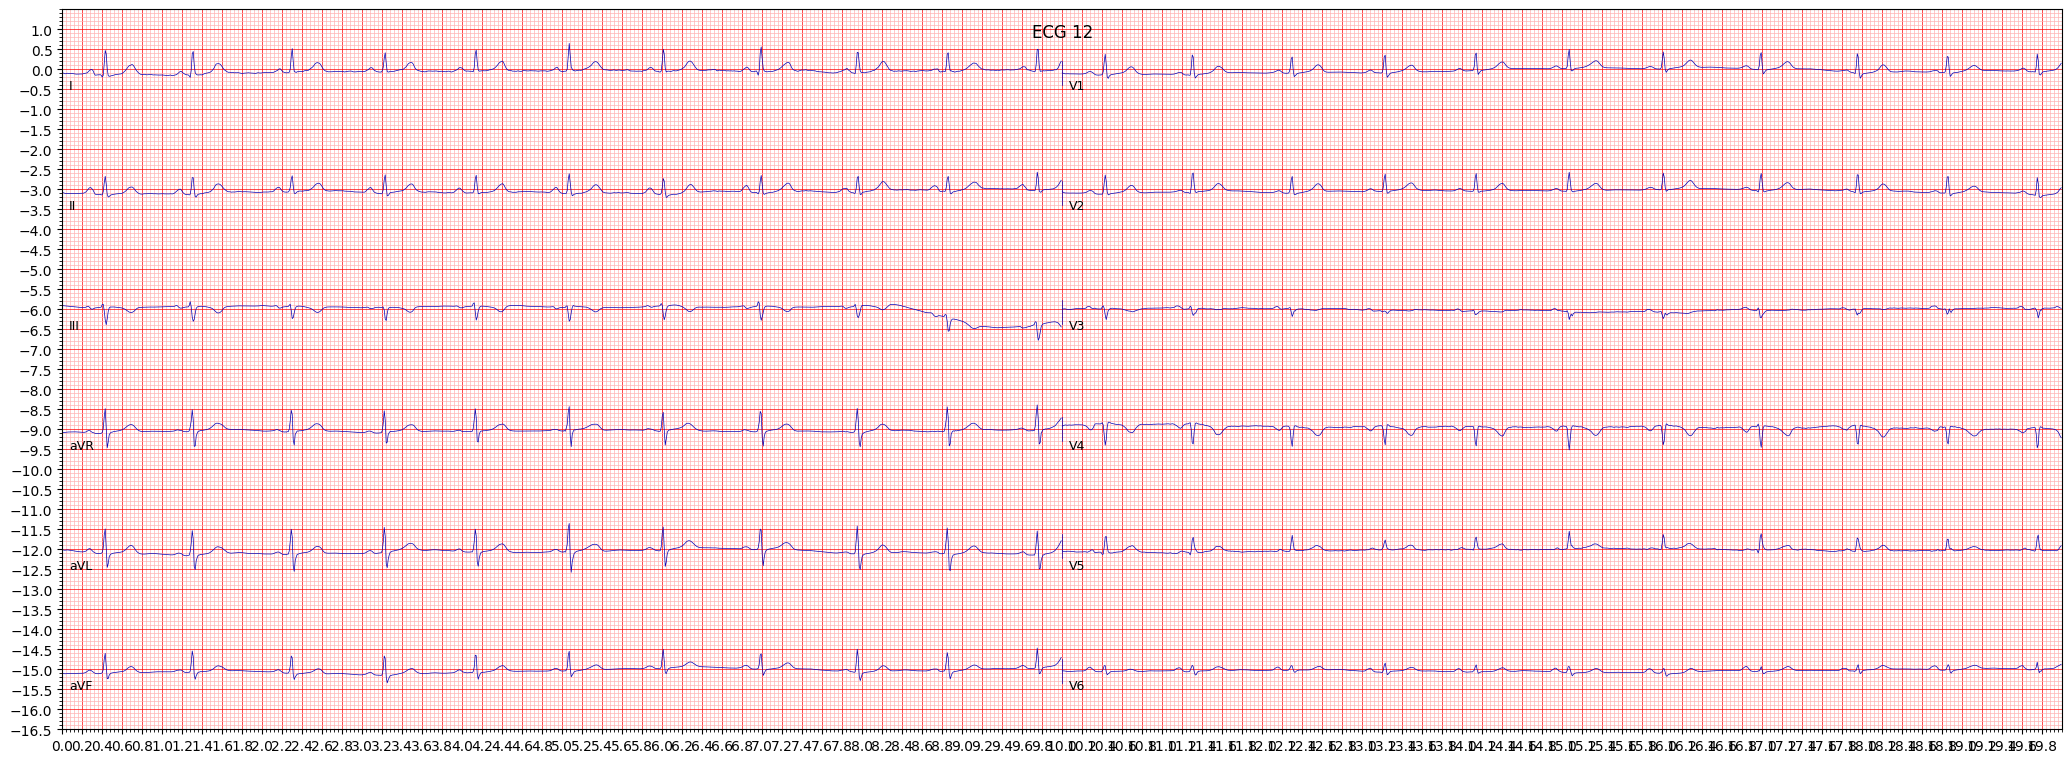

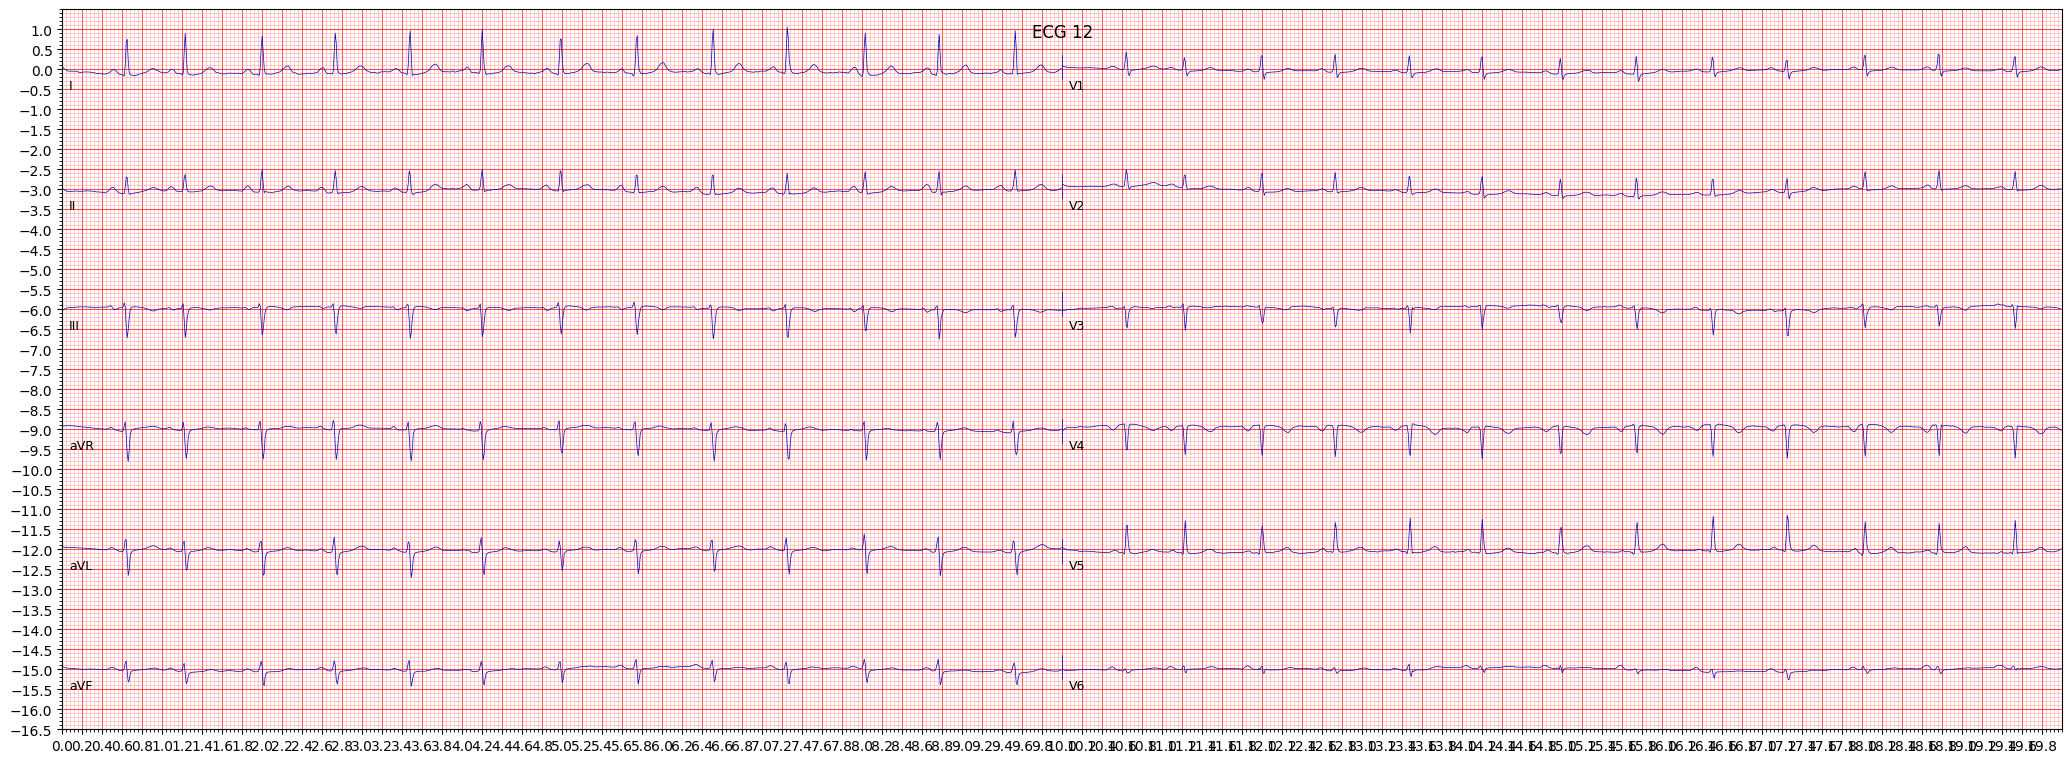

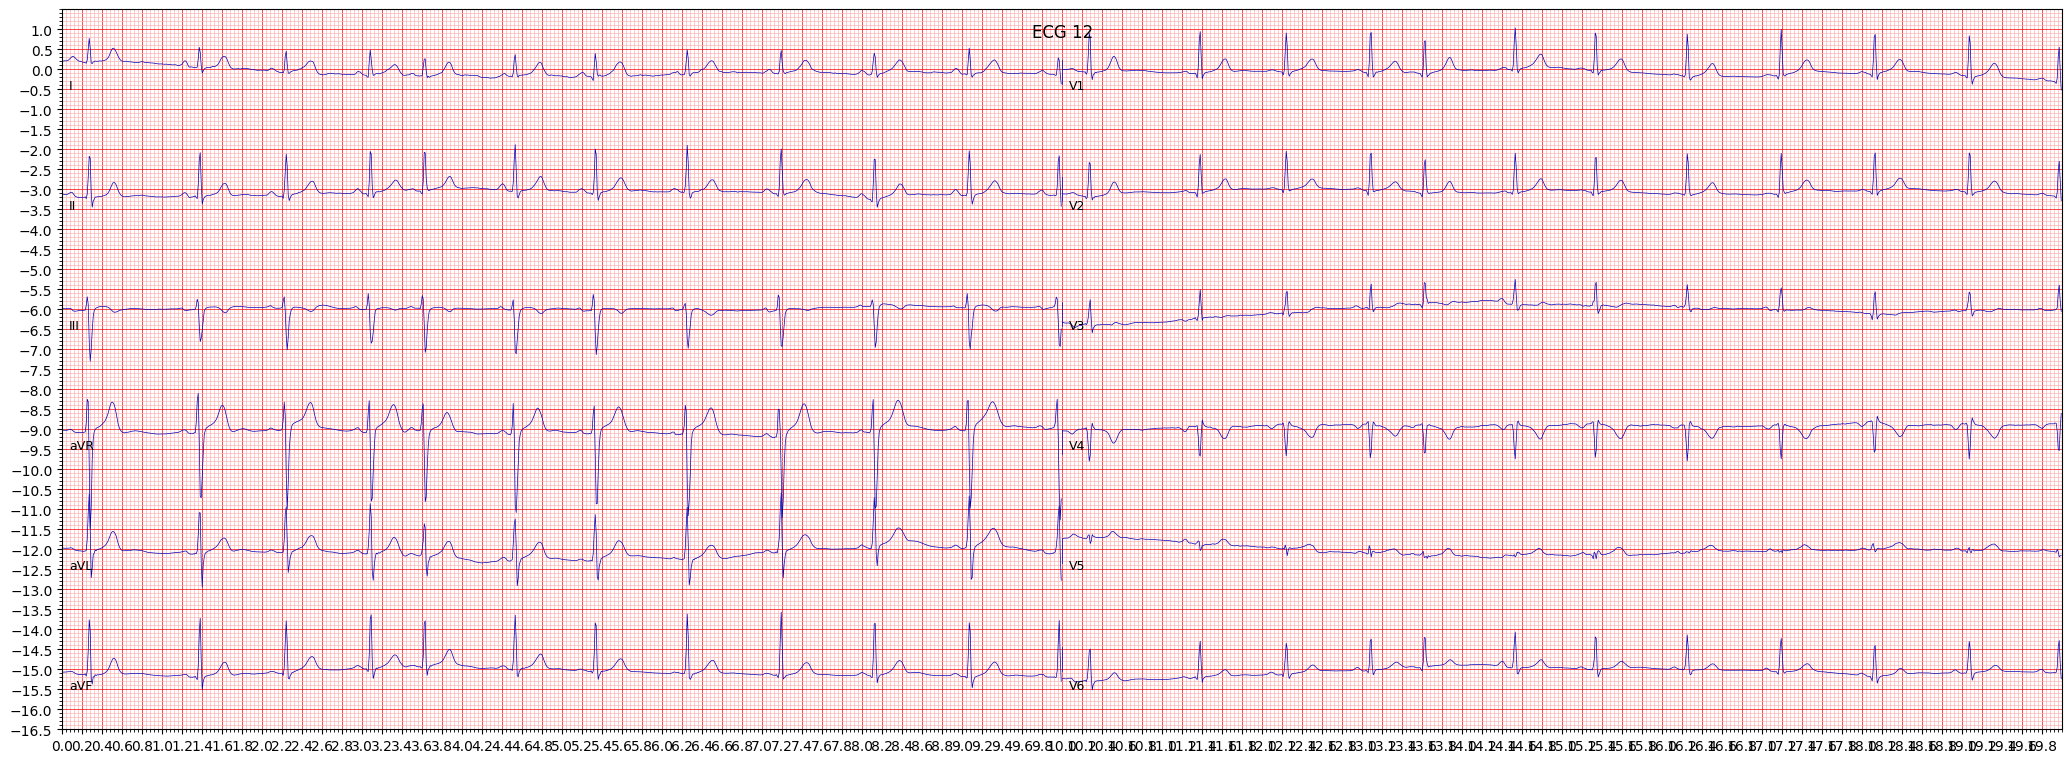

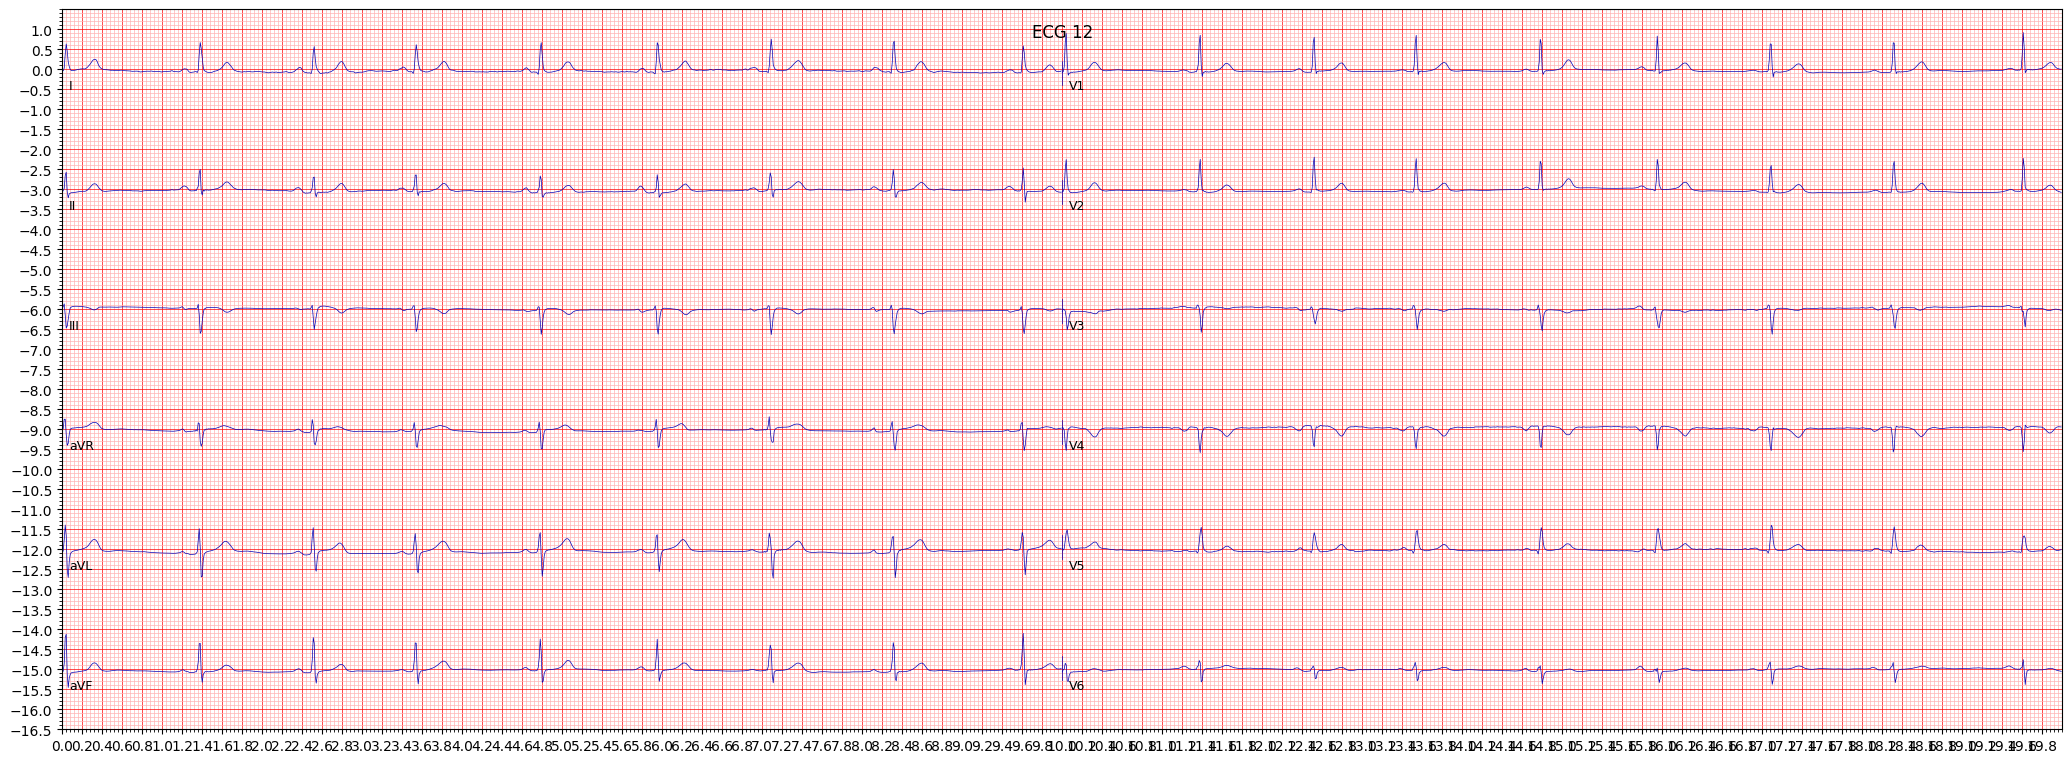

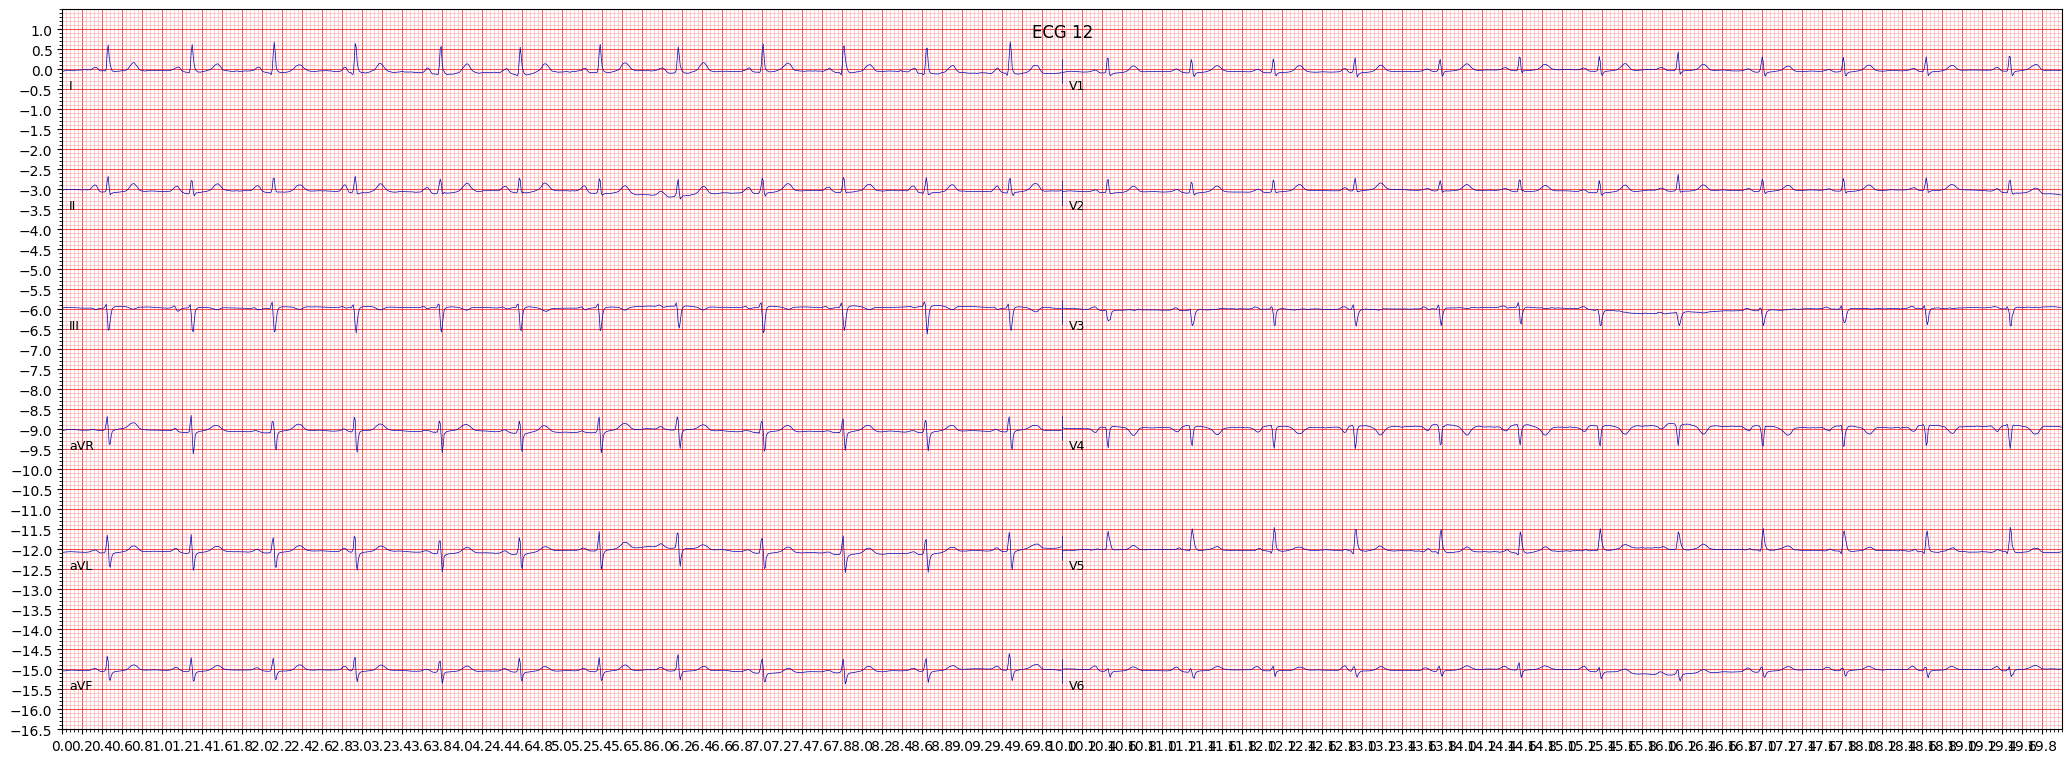

In [29]:
for i in range(10):
    signal = generated_audio12[i].cpu().numpy()
    ecg_plot.plot(signal, sample_rate = 100)

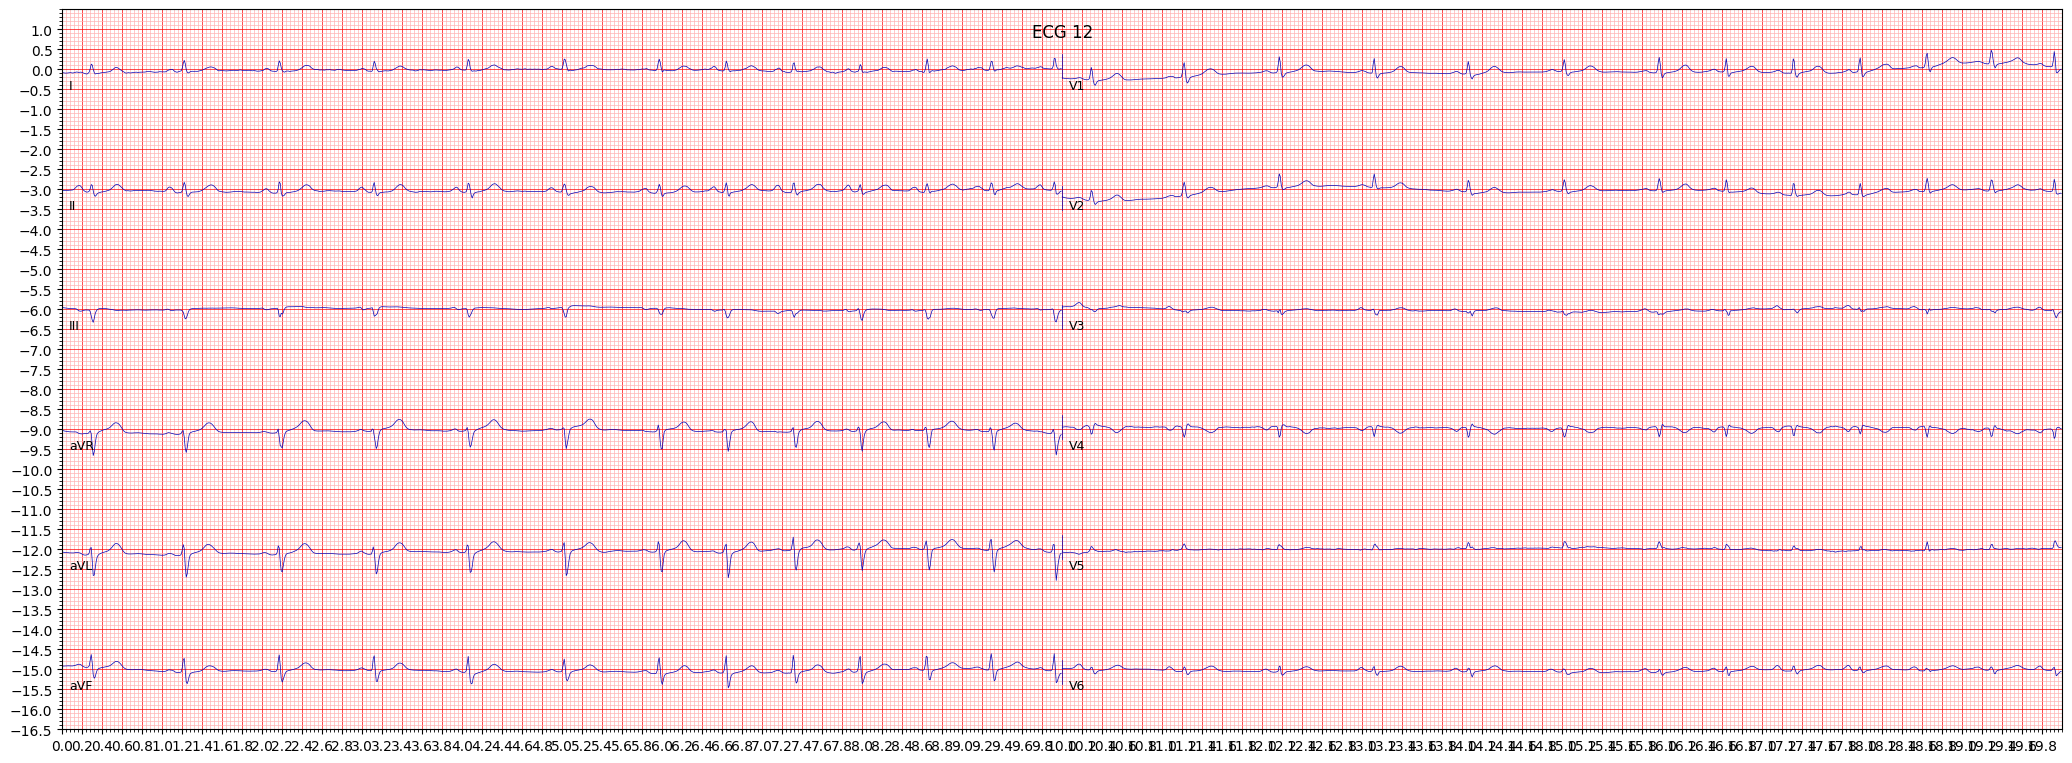

In [28]:
ecg_plot.plot(signal, sample_rate = 100)

- Convert the report into embeddings and perform inference on the PTB XL data. Use the generated ECG for downstream classification tasks.